In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
%matplotlib inline

In [141]:
words = open('names.txt', 'r').read().splitlines()

In [47]:
chars = sorted(list(set(''.join(words))))

stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [142]:
# build X, Y

X, Y = [], []
block_size = 3

for w in words:
    context = [0] * block_size
    for ch in list(w) + ['.']:
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape

torch.Size([228146, 3])

In [143]:
block_size = 3

def build_dataset(words):   
    X, Y = [], []
    
    for w in words:

        context = [0] * block_size
        for ch in list(w) + ['.']:
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [144]:
C = torch.randn((27, 2))
emb = C[X]
W1 = torch.randn((6, 100))
B1 = torch.randn(100)

W2 = torch.randn((100, 27))
B2 = torch.randn(27)

In [58]:
h = torch.tanh(emb.view(-1, 6) @ W1 + B1)
h.shape

torch.Size([32, 100])

In [59]:


logits = h @ W2 + B2
logits.shape

torch.Size([32, 27])

In [60]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)


In [65]:
loss = -prob[torch.arange(32), Y].log().mean()


tensor(12.9444)

In [179]:
C = torch.randn((27, 10))
W1 = torch.randn((30, 200))
B1 = torch.randn(200)

W2 = torch.randn((200, 27))
B2 = torch.randn(27)

In [180]:
parameters = [C, W1, W2, B1, B2]
for p in parameters:
    p.requires_grad = True

In [181]:
lri = []
lossi = []
stepi = []

In [ ]:


for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))

    emb = C[Xtr[ix]]

    # forward pass
    h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
    logits = h @ W2 + B2
    
    # instead of:
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdir=True)
    # loss = -prob[torch.arange(32), Y].log().mean()

    # do:
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)


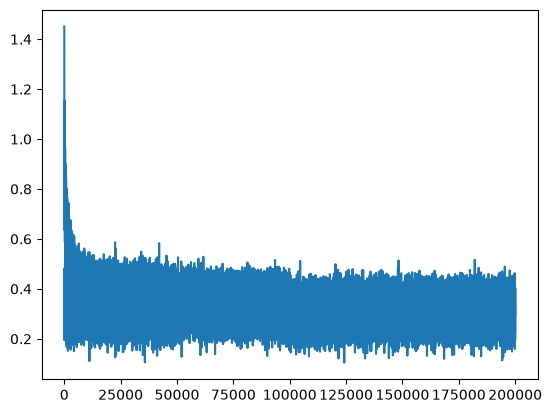

In [196]:
plt.plot(stepi, lossi)

In [197]:
emb = C[Xtr]

# forward pass
h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
logits = h @ W2 + B2
loss = F.cross_entropy(logits, Ytr)

print(loss.item())

2.0834689140319824


In [198]:
emb = C[Xdev]

# forward pass
h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
logits = h @ W2 + B2
loss = F.cross_entropy(logits, Ydev)

print(loss.item())

2.1347908973693848


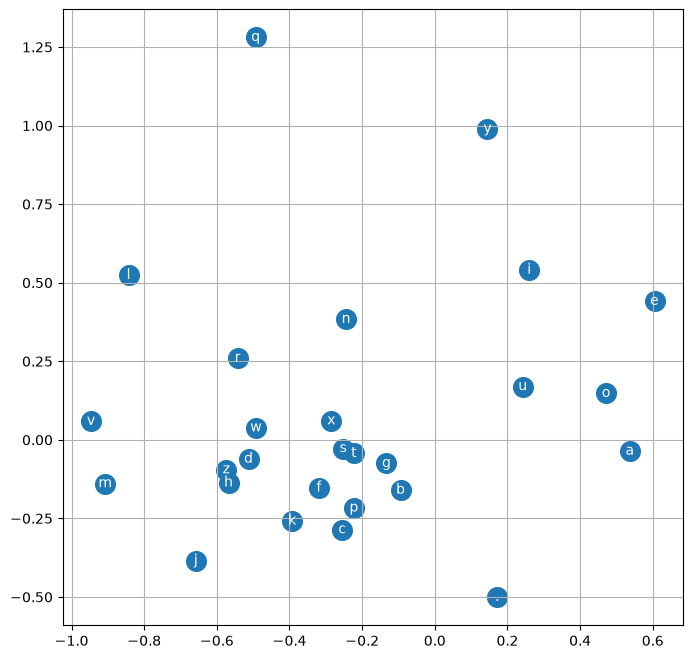

In [178]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', c='w')
plt.grid('minor')

In [199]:
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + B1)
      logits = h @ W2 + B2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

aletcee.
ekaemea.
arya.
osia.
bremayrund.
kambriel.
maryah.
tellonia.
novangali.
jamori.
kamaritenlifianlea.
karlynn.
kairiahlin.
kia.
miya.
desynck.
kenliya.
amalikim.
aana.
avari.
